---
title: EDA IV
---

::: {note} Learning Outcomes
* Compute group-wise attendance rates from suppressed counts, and test the conclusion by bounding the nulls with `fill_null`
* Keep rows that meet several conditions at once with a multi-predicate `.filter()`
* Group on two variables with `.group_by()` and read the result as one row per plotted point
* Encode a third variable with `hue=` in `sns.pointplot`, and explain what `px.scatter_3d` hides
* Compare groups in small multiples with `sns.relplot(col=...)`
* State the decisions that turn an open-ended question into an answer
:::

In this chapter, we will finish the UC Berkeley admissions case study. We will follow admitted students to attendance, bring distance in as a third variable, and make the decisions we need to hand our manager five schools.

Recall the task: your manager asks you to identify five California public high schools that defy typical patterns of application, admission, or attendance. Over the last three chapters, we have looked at each school's application rate, related it to the share of its students who qualify for free or reduced-price meals (FRL), and computed admission rates in the face of missing data. This chapter carries the analysis the rest of the way to an answer.

In [1]:
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

sns.set_palette("colorblind")
pl.Config.set_fmt_str_lengths(40)
pl.Config.set_tbl_rows(20);

## Where We Left Off

EDA III ended on two rates that move in different directions. For each FRL-percentile bucket, it computed the **application rate**, total applicants divided by total 12th graders, and the **admission rate**, total admits divided by total applicants. Because UC leaves counts below three blank, many schools have a null `admitted`, and EDA III replaced each one with a random 0, 1 or 2.

The code below rebuilds that state from the raw file, step for step and with the same random seed, so the numbers match EDA III's. It keeps the 1,229 schools whose application rate is at most 1, and it ends with a table of both rates for each bucket.

````{dropdown} Click to see the code
```python
labels = ["0-25", "25-50", "50-75", "75-100"]

# EDA I: load the data, compute application rates, drop impossible rates
admissions = pl.read_csv("data/pivoted-ucb-data-w-everything.csv")
admissions = admissions.with_columns(app_rate=pl.col("applied") / pl.col("grade_12"))
admissions = admissions.filter(pl.col("app_rate") <= 1)

# EDA III: each school's FRL percentile, then four equal-sized buckets
admissions = admissions.with_columns(
    frl_percentile_raw=pl.col("pct_free_reduced").rank() / pl.col("pct_free_reduced").count()
)
admissions = admissions.with_columns(
    frl_percentile=pl.col("frl_percentile_raw").qcut(4, labels=labels).cast(pl.String)
)
binned = admissions.filter(pl.col("frl_percentile").is_not_null())

# EDA III: replace each null admitted with a random 0, 1 or 2
rng = np.random.default_rng(7342)
replace_random = binned.with_columns(
    admitted=pl.when(pl.col("admitted").is_null())
    .then(pl.Series(rng.integers(0, 3, size=binned.height)))
    .otherwise(pl.col("admitted"))
)

# Both rates for each bucket
rates_by_frl = (
    replace_random.group_by("frl_percentile")
    .agg(
        avg_app_rate=pl.col("applied").sum() / pl.col("grade_12").sum(),
        admission_rate=pl.col("admitted").sum() / pl.col("applied").sum(),
    )
    .sort("frl_percentile")
)
rates_by_frl
```
````

In [2]:
labels = ["0-25", "25-50", "50-75", "75-100"]

# EDA I: load the data, compute application rates, drop impossible rates
admissions = pl.read_csv("data/pivoted-ucb-data-w-everything.csv")
admissions = admissions.with_columns(app_rate=pl.col("applied") / pl.col("grade_12"))
admissions = admissions.filter(pl.col("app_rate") <= 1)

# EDA III: each school's FRL percentile, then four equal-sized buckets
admissions = admissions.with_columns(
    frl_percentile_raw=pl.col("pct_free_reduced").rank() / pl.col("pct_free_reduced").count()
)
admissions = admissions.with_columns(
    frl_percentile=pl.col("frl_percentile_raw").qcut(4, labels=labels).cast(pl.String)
)
binned = admissions.filter(pl.col("frl_percentile").is_not_null())

# EDA III: replace each null admitted with a random 0, 1 or 2
rng = np.random.default_rng(7342)
replace_random = binned.with_columns(
    admitted=pl.when(pl.col("admitted").is_null())
    .then(pl.Series(rng.integers(0, 3, size=binned.height)))
    .otherwise(pl.col("admitted"))
)

# Both rates for each bucket
rates_by_frl = (
    replace_random.group_by("frl_percentile")
    .agg(
        avg_app_rate=pl.col("applied").sum() / pl.col("grade_12").sum(),
        admission_rate=pl.col("admitted").sum() / pl.col("applied").sum(),
    )
    .sort("frl_percentile")
)
rates_by_frl

frl_percentile,avg_app_rate,admission_rate
str,f64,f64
"""0-25""",0.256207,0.123421
"""25-50""",0.117248,0.129319
"""50-75""",0.087358,0.152007
"""75-100""",0.093879,0.148686


Plotting the two columns side by side makes the contrast easy to see.

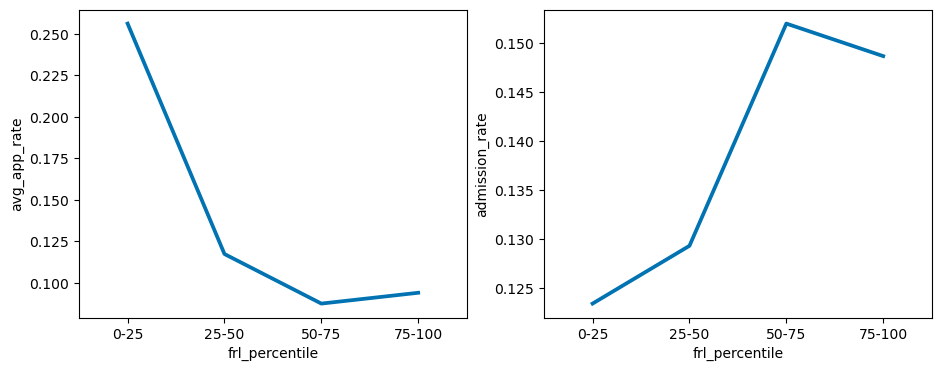

In [3]:
#| fig-alt: Two line plots side by side, each with one point per FRL-percentile bucket, 0-25, 25-50, 50-75 and 75-100. Left, avg_app_rate falls from 0.256 to 0.117 to 0.087, then edges up to 0.094. Right, admission_rate rises from 0.123 to 0.129 to 0.152, then dips to 0.149.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.pointplot(rates_by_frl, x="frl_percentile", y="avg_app_rate", order=labels, marker="", ax=axes[0])
sns.pointplot(rates_by_frl, x="frl_percentile", y="admission_rate", order=labels, marker="", ax=axes[1]);

The application rate falls from 0.256 in the `0-25` bucket to 0.087 in the `50-75` bucket, with a small uptick to 0.094 in `75-100`. The admission rate goes the other way: it rises from 0.123 to 0.152, then dips slightly to 0.149. Notice that the two panels have different y-axes, and that admission rates cover a much narrower range than application rates do.

Students at high-FRL schools are less likely to apply, but those who do apply are more likely to be admitted. So "students from high-FRL schools do worse" is not a single claim. Two steps of the same pipeline can move in opposite directions across the same groups, and any conclusion has to say which step it is about.

## Why Might Admission Rates Rise?

What could be responsible for the reversed pattern? The data we have cannot settle it, but we can state hypotheses precisely enough that someone could go and test them.

* **Selection effects.** At a school where few students apply, the ones who still apply may be the strongest students, the ones most confident of getting in. A school's applicants are then not a random sample of its 12th graders, and a low application rate can go hand in hand with a strong applicant pool.
* **Admissions policy.** UC considers how an applicant performed relative to other students at the same high school. Suppose that ranking near the top of one's own class carries real weight. At a school where only a handful of students apply, most of that handful may be near the top of their class, and so most of them may get in.

::: {note} Who is in the denominator?
Both hypotheses are about the group the admission rate divides by. The application rate divides by every 12th grader at a school, but the admission rate divides only by the students who chose to apply, and that group is itself the result of thousands of individual decisions. When two rates from the same pipeline disagree, ask whether the groups in their denominators were selected differently.
:::

## Attendance Rates and Missing Data, Again

The last step of the pipeline is attending. For each FRL bucket, we want the **attendance rate**, also called the **yield**: of the students UC Berkeley admitted, the fraction who chose to attend. As with the other two rates, we pool the counts within each bucket and divide the total number who attended by the total number admitted.

Attendance rates are trickier than admission rates, because both the numerator and the denominator can be missing. The first five schools already show both patterns.

In [4]:
admissions.select("school", "city", "applied", "admitted", "attended").head(5)

school,city,applied,admitted,attended
str,str,i64,i64,i64
"""A B MILLER HIGH SCHOOL""","""Fontana""",25,3,null
"""ABLE CHARTER""","""Stockton""",8,null,null
"""ABRAHAM LINCOLN HIGH SCHOOL""","""Los Angeles""",48,11,4
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Francisco""",201,33,23
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Jose""",56,8,3


A B Miller High School has 3 admitted students and a null `attended`. Able Charter has a null in both columns. How many schools fall into each case?

In [5]:
admissions.select("admitted", "attended").null_count()

admitted,attended
u32,u32
418,740


Of the 1,229 schools, 418 have no admit count and 740 have no attendance count. Before we decide what to do with them, two facts about how these nulls came about will do most of the deciding for us.

First, what does a null `attended` stand for? EDA III found that the smallest reported `admitted` is 3, which fits UC's practice of leaving counts below three blank. The same holds for `attended`:

In [6]:
admissions["attended"].min()

3

So a null in `attended` means that 0, 1 or 2 admitted students attended.

Second, is `attended` ever known when `admitted` is not? Answering this takes a filter with two conditions. `.filter()` accepts several conditions separated by commas, and it keeps only the rows where every one of them holds.

In English: *keep the schools whose `admitted` is null and whose `attended` is not null, and count them.*

In [7]:
admissions.filter(pl.col("admitted").is_null(), pl.col("attended").is_not_null()).height

0

In SQL, the conditions are joined with `AND`. Here and in the rest of the chapter, a table name in a SQL block stands for the frame of the same name at that point in the chapter, including any columns we have added to it.

```sql
SELECT COUNT(*)
FROM admissions
WHERE admitted IS NULL AND attended IS NOT NULL
```

There are none. Whenever `admitted` is null, `attended` is null too, which makes sense: if at most 2 students were admitted, at most 2 could attend, and that count would be suppressed as well.

These two facts justify one reasonable approach:

1. **Ignore the schools where `admitted` and `attended` are both null.** Since `attended` is never known without `admitted`, this is the same as dropping the 418 schools with no admit count. Without a denominator, a school has nothing to contribute to an attendance rate.
2. **For the schools that remain, replace a null `attended` with a random 0, 1 or 2**, just as EDA III did for `admitted`. A random value of at most 2 can never exceed a school's `admitted`, which is at least 3.

Each part of this rule rests on how UC suppressed the counts, which is what makes it more than a convenient guess.

In English: *keep the schools whose `admitted` is not null. Count them, and count how many have a null `attended`.* `.select()` accepts named expressions just as `.with_columns()` does, and here each one reduces the frame to a single number.

In [8]:
attendance = admissions.filter(pl.col("admitted").is_not_null())
attendance.select(schools=pl.len(), null_attended=pl.col("attended").null_count())

schools,null_attended
u32,u32
811,322


In SQL, `COUNT(attended)` counts only the non-null values of `attended`, so subtracting it from `COUNT(*)` counts the nulls.

```sql
SELECT COUNT(*) AS schools, COUNT(*) - COUNT(attended) AS null_attended
FROM admissions
WHERE admitted IS NOT NULL
```

That leaves 811 schools, and 322 of them have a suppressed `attended`. We fill those in next. The new values go in a new column, `attended_random`, and the original `attended` stays as it was, because the next section compares this choice with others.

In English: *where `attended` is null, use a random whole number from 0 to 2. Otherwise, keep `attended`.* The seed, 7342, is the one EDA III used, and it makes the draw the same every time this page is built.

In [9]:
rng = np.random.default_rng(7342)
attendance = attendance.with_columns(
    attended_random=pl.when(pl.col("attended").is_null())
    .then(pl.Series(rng.integers(0, 3, size=attendance.height)))
    .otherwise(pl.col("attended"))
)
attendance.select("school", "city", "admitted", "attended", "attended_random").head(5)

school,city,admitted,attended,attended_random
str,str,i64,i64,i64
"""A B MILLER HIGH SCHOOL""","""Fontana""",3,null,0
"""ABRAHAM LINCOLN HIGH SCHOOL""","""Los Angeles""",11,4,4
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Francisco""",33,23,23
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Jose""",8,3,3
"""ACADEMIES EDUCATION/EMPOWERMNT""","""Carson""",6,4,4


Able Charter, with no admit count, is gone. A B Miller High School's null became 0 in `attended_random`, and every school with a reported `attended` kept its count.

In SQL, `RANDOM()` returns a number between 0 and 1, so `FLOOR(RANDOM() * 3)` is 0, 1 or 2.

```sql
SELECT *,
       CASE WHEN attended IS NULL THEN CAST(FLOOR(RANDOM() * 3) AS INTEGER)
            ELSE attended END AS attended_random
FROM admissions
WHERE admitted IS NOT NULL
```

DuckDB draws from its own random number generator, not NumPy's, so this query fills in different values from the Polars cell. Only its shape matches.

## Attendance Rates Fall as FRL Rises

With every remaining school's `attended` filled in, we can compute attendance rates. As in EDA III, the schools with no FRL bucket are filtered out first, so that they do not form a group of their own.

In English: *for each FRL bucket, divide the total of `attended_random` by the total of `admitted`.*

In [10]:
attend_by_frl = (
    attendance.filter(pl.col("frl_percentile").is_not_null())
    .group_by("frl_percentile")
    .agg(attendance_rate=pl.col("attended_random").sum() / pl.col("admitted").sum())
    .sort("frl_percentile")
)
attend_by_frl

frl_percentile,attendance_rate
str,f64
"""0-25""",0.566605
"""25-50""",0.498998
"""50-75""",0.462838
"""75-100""",0.419704


```sql
SELECT frl_percentile, SUM(attended_random) / SUM(admitted) AS attendance_rate
FROM attendance
WHERE frl_percentile IS NOT NULL
GROUP BY frl_percentile
ORDER BY frl_percentile
```

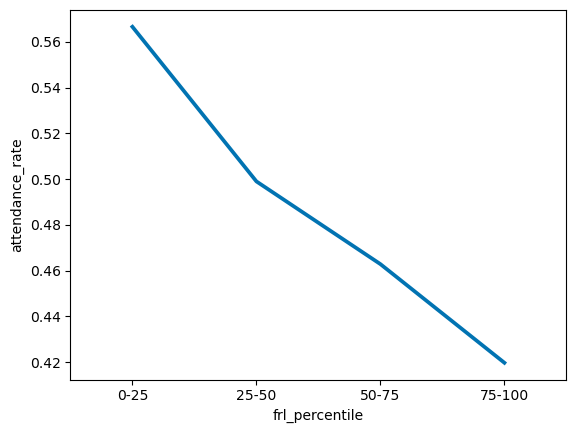

In [11]:
#| fig-alt: A line plot of attendance_rate against frl_percentile, one point per bucket from 0-25 to 75-100. The line falls steadily, from 0.567 to 0.499 to 0.463 to 0.420.
sns.pointplot(attend_by_frl, x="frl_percentile", y="attendance_rate", order=labels, marker="");

Attendance rates fall steadily as FRL rises, from 0.567 in the `0-25` bucket to 0.420 in `75-100`. This is yet another pattern. High-FRL schools apply at lower rates and are admitted at higher rates, and now their admitted students attend at lower rates. What's going on here? Two hypotheses:

* **Attending college is expensive.** An admitted student from a lower-income family may weigh cost more heavily, and choose a school closer to home or one that offers more aid.
* **Berkeley may be compensating.** If UC Berkeley knows that yield is lower at high-FRL schools, it may admit more students from those schools to make up for it. That would connect this plot to the rising admission rates we started with.

### Is the Pattern Stable?

Before building on this plot, we should check how much it depends on our random imputation. EDA III introduced the stability check from the PCS framework: does a conclusion survive reasonable changes to the analysis? Here the missing values have hard limits, since each suppressed `attended` is 0, 1 or 2. Filling every one with 0 gives the lowest rate each bucket could have, and filling every one with 2 gives the highest, so the true rate of each bucket lies somewhere in that range. For one bucket to attend at a higher rate than another whatever the suppressed counts are, its lowest possible rate has to beat the other's highest.

Inside `.agg()`, an expression can be transformed before it is aggregated. `pl.col("attended").fill_null(0).sum()` fills the nulls in each bucket with 0 and then adds up the result. One `.agg()` can hold several such named expressions, and each becomes a column. We also record the share of schools in each bucket whose `attended` was suppressed, dividing the number of nulls, `null_count()`, by the number of rows, `pl.len()`.

In English: *for each FRL bucket, compute the attendance rate three ways, with the nulls filled by 0, by the random draw, and by 2. Also compute the share of schools whose `attended` is null.*

In [12]:
bounds_by_frl = (
    attendance.filter(pl.col("frl_percentile").is_not_null())
    .group_by("frl_percentile")
    .agg(
        fill_0=pl.col("attended").fill_null(0).sum() / pl.col("admitted").sum(),
        fill_random=pl.col("attended_random").sum() / pl.col("admitted").sum(),
        fill_2=pl.col("attended").fill_null(2).sum() / pl.col("admitted").sum(),
        share_null=pl.col("attended").null_count() / pl.len(),
    )
    .sort("frl_percentile")
)
bounds_by_frl

frl_percentile,fill_0,fill_random,fill_2,share_null
str,f64,f64,f64,f64
"""0-25""",0.554735,0.566605,0.57742,0.17551
"""25-50""",0.44823,0.498998,0.545758,0.394595
"""50-75""",0.375845,0.462838,0.534628,0.531073
"""75-100""",0.330049,0.419704,0.525123,0.565714


In SQL, `COALESCE` does the filling, as it did in EDA III.

```sql
SELECT frl_percentile,
       SUM(COALESCE(attended, 0)) / SUM(admitted) AS fill_0,
       SUM(attended_random) / SUM(admitted) AS fill_random,
       SUM(COALESCE(attended, 2)) / SUM(admitted) AS fill_2,
       (COUNT(*) - COUNT(attended)) / COUNT(*) AS share_null
FROM attendance
WHERE frl_percentile IS NOT NULL
GROUP BY frl_percentile
ORDER BY frl_percentile
```

Three things stand out in this table.

* **The choice matters most where we are comparing.** The share of schools with a suppressed `attended` climbs from 18% in the `0-25` bucket to 57% in `75-100`.
* **The top bucket is settled.** The true attendance rate lies between `fill_0` and `fill_2`. The lower bound for the `0-25` bucket, 0.555, is higher than the upper bound of every other bucket (0.546, 0.535 and 0.525). So students admitted from low-FRL schools attend at a higher rate, whatever the suppressed counts really are.
* **The size is not.** With every null filled by 0, the rate falls from 0.555 to 0.330 across the buckets. With every null filled by 2, it falls only from 0.577 to 0.525. The order of the three higher buckets is not settled either: the range for `25-50`, from 0.448 to 0.546, overlaps the ranges of both buckets above it.

::: {tip} Compare ranges, not fills
When missing values have known limits, fill them with each extreme to get a range for every group. One group is higher than another for certain only when its whole range lies above the other's. Where the ranges overlap, the data cannot settle the order, whichever fill we choose.
:::

## Bringing in a Third Variable: Distance

So far, every comparison has split the schools on one variable. Distance to Berkeley may matter too. Holding FRL status constant, perhaps students at schools closer to Berkeley are more likely to apply, and to attend, than students at schools far away. We will look at applying, the step where every school has a count and nothing needs to be imputed.

To compare distance groups, we split the schools into four equal-sized groups by `dist_to_ucb_miles`, just as EDA III did for FRL. EDA III got there in two steps, a percentile with `.rank()` followed by `.qcut()`. Here we pass the distances to `.qcut()` directly. It cuts at the quartiles of whatever values it is given, and for these 1,229 schools the one-step and two-step routes put every school in the same bucket.

In [13]:
admissions = admissions.with_columns(
    dist_percentile=pl.col("dist_to_ucb_miles").qcut(4, labels=labels).cast(pl.String)
)
dist_ranges = (
    admissions.group_by("dist_percentile")
    .agg(
        schools=pl.len(),
        min_miles=pl.col("dist_to_ucb_miles").min(),
        max_miles=pl.col("dist_to_ucb_miles").max(),
    )
    .sort("dist_percentile")
)
dist_ranges

dist_percentile,schools,min_miles,max_miles
str,u32,f64,f64
"""0-25""",308,0.682117,67.363956
"""25-50""",307,67.606742,316.683921
"""50-75""",307,317.060889,362.592695
"""75-100""",307,362.674069,523.916547


In SQL, EDA III's `NTILE` does the same job. It numbers the quarters 1 to 4 where `qcut` labels them, and it splits the rows by count where `qcut` cuts at quantile values. On these 1,229 schools, the two put every school in the same quarter.

```sql
SELECT school, city, dist_to_ucb_miles,
       NTILE(4) OVER (ORDER BY dist_to_ucb_miles) AS dist_quartile
FROM admissions
```

Each quartile holds 307 or 308 schools, but they cover very different distances. The nearest quartile runs out to 67 miles. The next spans nearly 250 miles, from 68 to 317. The third covers less than 50 miles, from 317 to 363, and the farthest runs from 363 to 524 miles. We will come back to why.

Now we group on both bucket columns at once. Grouping on two columns makes one group for each combination of their values, so four FRL buckets and four distance buckets give 16 groups. Sorting on both keys puts the rows in a fixed order.

In English: *for each combination of FRL bucket and distance bucket, add up `applied` and `grade_12`, and divide the first total by the second.*

In [14]:
app_by_frl_dist = (
    admissions.filter(pl.col("frl_percentile").is_not_null())
    .group_by("frl_percentile", "dist_percentile")
    .agg(
        applied=pl.col("applied").sum(),
        grade_12=pl.col("grade_12").sum(),
        app_rate=pl.col("applied").sum() / pl.col("grade_12").sum(),
    )
    .sort("frl_percentile", "dist_percentile")
)
app_by_frl_dist

frl_percentile,dist_percentile,applied,grade_12,app_rate
str,str,i64,i64,f64
"""0-25""","""0-25""",15232,45872,0.332054
"""0-25""","""25-50""",2785,20277,0.137348
"""0-25""","""50-75""",4301,15776,0.272629
"""0-25""","""75-100""",8803,39543,0.222618
"""25-50""","""0-25""",4274,27016,0.158203
"""25-50""","""25-50""",2338,29171,0.080148
"""25-50""","""50-75""",2159,13589,0.158879
"""25-50""","""75-100""",3586,35616,0.100685
"""50-75""","""0-25""",1893,14992,0.126267


```sql
SELECT frl_percentile, dist_percentile,
       SUM(applied) AS applied,
       SUM(grade_12) AS grade_12,
       SUM(applied) / SUM(grade_12) AS app_rate
FROM admissions
WHERE frl_percentile IS NOT NULL
GROUP BY frl_percentile, dist_percentile
ORDER BY frl_percentile, dist_percentile
```

How should we plot 16 rows and three variables, two bucket columns and a rate? A three-dimensional scatter plot gives each variable its own axis. `px.scatter_3d`, from the plotly library, draws one from a `DataFrame`, and its `category_orders` argument sets the order of the labels on each categorical axis.

In [15]:
#| fig-alt: An interactive 3D scatter plot of 16 points. The two floor axes are dist_percentile and frl_percentile, each with four buckets from 0-25 to 75-100, and the vertical axis is app_rate, from about 0.07 to 0.33. Seen from any single angle, the heights of the points are hard to compare.
px.scatter_3d(
    app_by_frl_dist,
    x="dist_percentile",
    y="frl_percentile",
    z="app_rate",
    category_orders={"dist_percentile": labels, "frl_percentile": labels},
)

How readable is this plot? You can drag it to rotate it, and even then it takes real effort to tell which of two points sits higher, or to follow one distance bucket across the four FRL buckets. Our data has three dimensions, but a page has two.

We are not stuck, though. Position is only one of the channels a plot can use to show a variable. Color, size, shape, line type and shading can each carry one too.

## Adding a Variable With Color

The same 16 rows can go into a two-dimensional plot, with the third variable carried by color. The `hue=` argument tells `sns.pointplot` which column to map to color, and it draws one line for each value of that column. `hue_order=` fixes the order of those values, and so the order of the colors and of the legend.

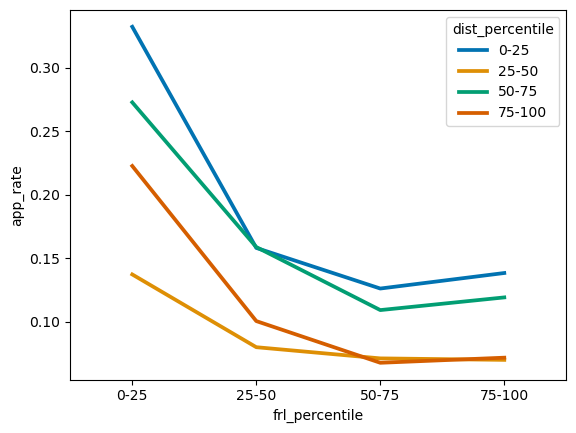

In [16]:
#| fig-alt: A line plot of app_rate against frl_percentile with four colored lines, one per dist_percentile bucket. Every line falls from the 0-25 FRL bucket to the 50-75 bucket. The 0-25 distance line is highest in three of the four FRL buckets, and the 25-50 distance line is lowest in three of the four, starting at 0.137 against 0.223 to 0.332 for the other lines.
sns.pointplot(
    app_by_frl_dist,
    x="frl_percentile",
    y="app_rate",
    hue="dist_percentile",
    order=labels,
    hue_order=labels,
    marker="",
);

This is the same data as the 3D plot. How would you describe its patterns to someone else? Reading carefully against the table above:

* Every line falls from the `0-25` FRL bucket to the `50-75` bucket, and three of the four tick up slightly at `75-100`, as the overall application rate did. Holding distance roughly constant, the FRL pattern from the start of the chapter still holds.
* The nearest schools, the `0-25` distance line, apply at the highest rate in three of the four FRL buckets. In the `25-50` FRL bucket, the `50-75` distance bucket edges past them, 0.159 to 0.158.
* The `25-50` distance line is the lowest in three of the four FRL buckets, and at low FRL it sits far below the rest: 0.137, against 0.223 to 0.332 for the other three.

Is anything unexpected here? If distance alone mattered, the lines would stack in order, with the nearest schools on top and the farthest at the bottom. Instead, the `25-50` line sits at the bottom. One hypothesis is that it has something to do with schools in the Central Valley, such as those in Bakersfield. Perhaps applying to Berkeley is less customary there.

We can check which schools make up that bucket. Comparing a string column to a string with `==` keeps the rows whose value matches exactly.

In English: *keep the schools in the `25-50` distance bucket. For each county, count the schools, and show the counties with the most.* Sorting on `county` as a second key breaks ties in the count alphabetically.

In [17]:
(
    admissions.filter(pl.col("dist_percentile") == "25-50")
    .group_by("county")
    .len()
    .sort("len", "county", descending=[True, False])
    .head(6)
)

county,len
str,u32
"""Fresno""",35
"""Kern""",30
"""Sacramento""",24
"""Ventura""",20
"""Stanislaus""",19
"""Tulare""",19


```sql
SELECT county, COUNT(*) AS len
FROM admissions
WHERE dist_percentile = '25-50'
GROUP BY county
ORDER BY len DESC, county
LIMIT 6
```

Five of these six counties are in the Central Valley: Fresno, Kern (home to Bakersfield), Sacramento, Stanislaus and Tulare. Ventura, on the coast northwest of Los Angeles, is the exception. The hypothesis survives this check, although counting counties cannot tell us *why* these schools apply at low rates.

The same check on the next bucket, `50-75`, is just as telling.

In [18]:
(
    admissions.filter(pl.col("dist_percentile") == "50-75")
    .group_by("county")
    .len()
    .sort("len", "county", descending=[True, False])
    .head(3)
)

county,len
str,u32
"""Los Angeles""",294
"""San Bernardino""",8
"""Ventura""",5


Of the 307 schools in the `50-75` distance bucket, 294 are in Los Angeles County, and the other 13 are in San Bernardino and Ventura. This is why the bucket is so narrow. Buckets of equal size are narrow wherever schools are packed close together, and a quarter of all the schools in our data fit into this one stretch of the Los Angeles area.

EDA I found three peaks in the distribution of `dist_to_ucb_miles`, one each for the Bay Area, Los Angeles and San Diego. Drawing the quartile boundaries on that histogram shows how the buckets line up with them. `plt.axvline` draws a vertical line across a plot at a given x-value. We draw one at the largest distance in each of the first three quartiles, taken from `dist_ranges`. Its `max_miles` column is a `Series`, and `cutoffs[0]` is that Series' first value by position, counting from 0, just as with a Python list. `dist_ranges` is sorted by `dist_percentile`, so positions 0, 1 and 2 are the first three quartiles.

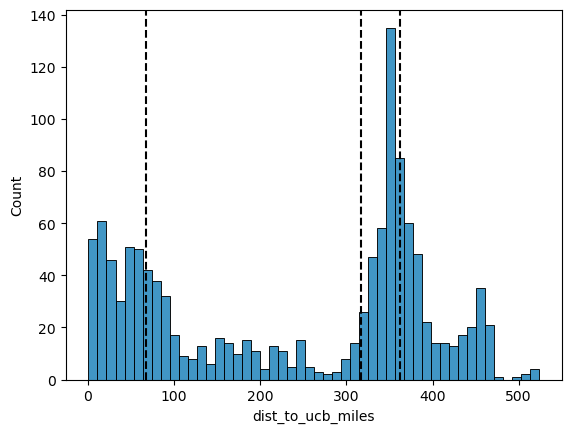

In [19]:
#| fig-alt: A 50-bin histogram of dist_to_ucb_miles from 0 to about 525 miles with three clusters, the Bay Area from 0 to about 100 miles, Los Angeles from about 300 to 400 miles with the tallest bar near 350 miles at about 135 schools, and a smaller San Diego peak near 455 miles. Dashed vertical lines at 67, 317 and 363 miles mark the quartile boundaries. The first line cuts through the outer edge of the Bay Area cluster, the first and second lines bracket the long, low stretch between the Bay Area and Los Angeles, and the second and third lines bracket the tallest part of the Los Angeles peak.
cutoffs = dist_ranges["max_miles"]
sns.histplot(admissions, x="dist_to_ucb_miles", bins=50)
plt.axvline(cutoffs[0], color="black", linestyle="--")
plt.axvline(cutoffs[1], color="black", linestyle="--")
plt.axvline(cutoffs[2], color="black", linestyle="--");

The first boundary cuts through the outer edge of the Bay Area cluster. From there, the `25-50` bucket runs across the long, low stretch between the Bay Area and Los Angeles, where the counties we just counted sit. The `50-75` bucket is the tallest part of the Los Angeles peak, and the `75-100` bucket is everything beyond it, from the far side of that peak through San Diego.

Here a distance quartile is really a region, and a careful reading has to say which region. "Schools 68 to 317 miles from Berkeley apply at low rates" is accurate, but "Central Valley schools apply at low rates" is closer to what the plot is showing us, and it is the version a manager can act on.

## Tidy Data, Redux

How many rows and columns does the data behind the color plot need? Count the points and the variables:

* The plot has 16 points, so the data needs 16 rows.
* The plot encodes 3 variables, `frl_percentile` on the x-axis, `app_rate` on the y-axis and `dist_percentile` as color, so the data needs 3 columns.

In [20]:
app_by_frl_dist.select("frl_percentile", "dist_percentile", "app_rate")

frl_percentile,dist_percentile,app_rate
str,str,f64
"""0-25""","""0-25""",0.332054
"""0-25""","""25-50""",0.137348
"""0-25""","""50-75""",0.272629
"""0-25""","""75-100""",0.222618
"""25-50""","""0-25""",0.158203
"""25-50""","""25-50""",0.080148
"""25-50""","""50-75""",0.158879
"""25-50""","""75-100""",0.100685
"""50-75""","""0-25""",0.126267


The shape, 16 rows and 3 columns, is exactly the plot. Every channel in the `sns.pointplot` call, `x`, `y` and `hue`, names a column, and every plotted point is a row. The `applied` and `grade_12` columns in `app_by_frl_dist` were there to compute `app_rate`; the plot never uses them.

## Returning to Our Original Question

We have learned a lot so far:

* High-FRL schools tend to have lower application rates, higher admission rates and lower attendance rates.
* Schools far from Berkeley tend to have lower application rates, but not in a steady progression. The nearest quartile applies at the highest rate in three of the four FRL buckets, and the Los Angeles quartile applies at a higher rate than the buckets on either side of it in every FRL bucket.
* Schools in the Central Valley tend to have especially low application rates, even though they are closer to Berkeley than schools in Los Angeles or San Diego.

There is a lot more to explore. How does distance relate to admission and attendance rates? How do charter schools compare to other schools? Large schools to small ones? Are there similar patterns for UCLA, which is something like the Berkeley of Southern California?

We could keep exploring, but our manager wants an answer. To pick five schools, we first have to decide which schools we are picking from. Some of the decisions this forces:

* Should we exclude small schools?
* Should we exclude charter schools?
* Do we care most about application, admission or attendance?
* Should our schools represent California as a whole? For example, is it all right if every one of them is in the Bay Area?
* Should we consider schools whose admission or attendance counts we imputed?

None of these questions has an answer in the data. An open-ended task ends when we make decisions like these and state them, not when the data runs out.

## One Way to Pick Five Schools

Here is one way to approach the problem. There is no single correct way.

* Focus on schools with at least 100 12th graders.
* Ignore charter schools.
* Focus on application rates, since applying is a single student action that an outreach visit could target. We are open to a school with either an unusually low or an unusually high rate.
* For geographic representation, split the schools into five distance buckets and pick one school from each.

We will plot `pct_free_reduced` against `app_rate`, so we also need each school's `pct_free_reduced` to be known. That requirement and the first two decisions go into a single `.filter()`.

In English: *keep the schools with at least 100 12th graders, that are not charter schools, and whose `pct_free_reduced` is not null.*

In [21]:
pool = admissions.filter(
    pl.col("grade_12") >= 100,
    pl.col("is_charter") == "N",
    pl.col("pct_free_reduced").is_not_null(),
)
pool.height

883

```sql
SELECT COUNT(*)
FROM admissions
WHERE grade_12 >= 100
  AND is_charter = 'N'
  AND pct_free_reduced IS NOT NULL
```

Our pool has 883 schools. Next, we split them into five distance buckets of equal size, with the same `qcut` as before.

In English: *split the pool into five equal-sized groups by distance, and count the schools in each.*

In [22]:
quintiles = [
    "1st distance quintile",
    "2nd distance quintile",
    "3rd distance quintile",
    "4th distance quintile",
    "5th distance quintile",
]
pool = pool.with_columns(
    dist_bucket=pl.col("dist_to_ucb_miles").qcut(5, labels=quintiles).cast(pl.String)
)
pool.group_by("dist_bucket").len().sort("dist_bucket")

dist_bucket,len
str,u32
"""1st distance quintile""",177
"""2nd distance quintile""",176
"""3rd distance quintile""",177
"""4th distance quintile""",176
"""5th distance quintile""",177


```sql
SELECT school, city, dist_to_ucb_miles,
       NTILE(5) OVER (ORDER BY dist_to_ucb_miles) AS dist_quintile
FROM pool
```

Here the two approaches do not quite agree. `qcut` puts 177, 176, 177, 176 and 177 schools in the five buckets. `NTILE(5)` deals out the 883 rows as evenly as it can and gives the leftover rows to the first buckets, which makes 177, 177, 177, 176 and 176. As a result, three schools that sit right at a cut point land one bucket lower in SQL.

Now we can draw the plot the decisions call for: a scatter plot of `pct_free_reduced` against `app_rate` for each of the five distance buckets. Several small plots of the same kind, one per group, are called **small multiples**. `sns.relplot` draws them: `col=` names the column whose values get one panel each, `col_wrap=3` starts a new row of panels after every three, and `col_order=` sets the order of the panels. As in EDA II, `size=` sizes each point by a column, and `sns.relplot` uses one size scale for every panel, so a dot of a given size means the same number of 12th graders wherever it appears.

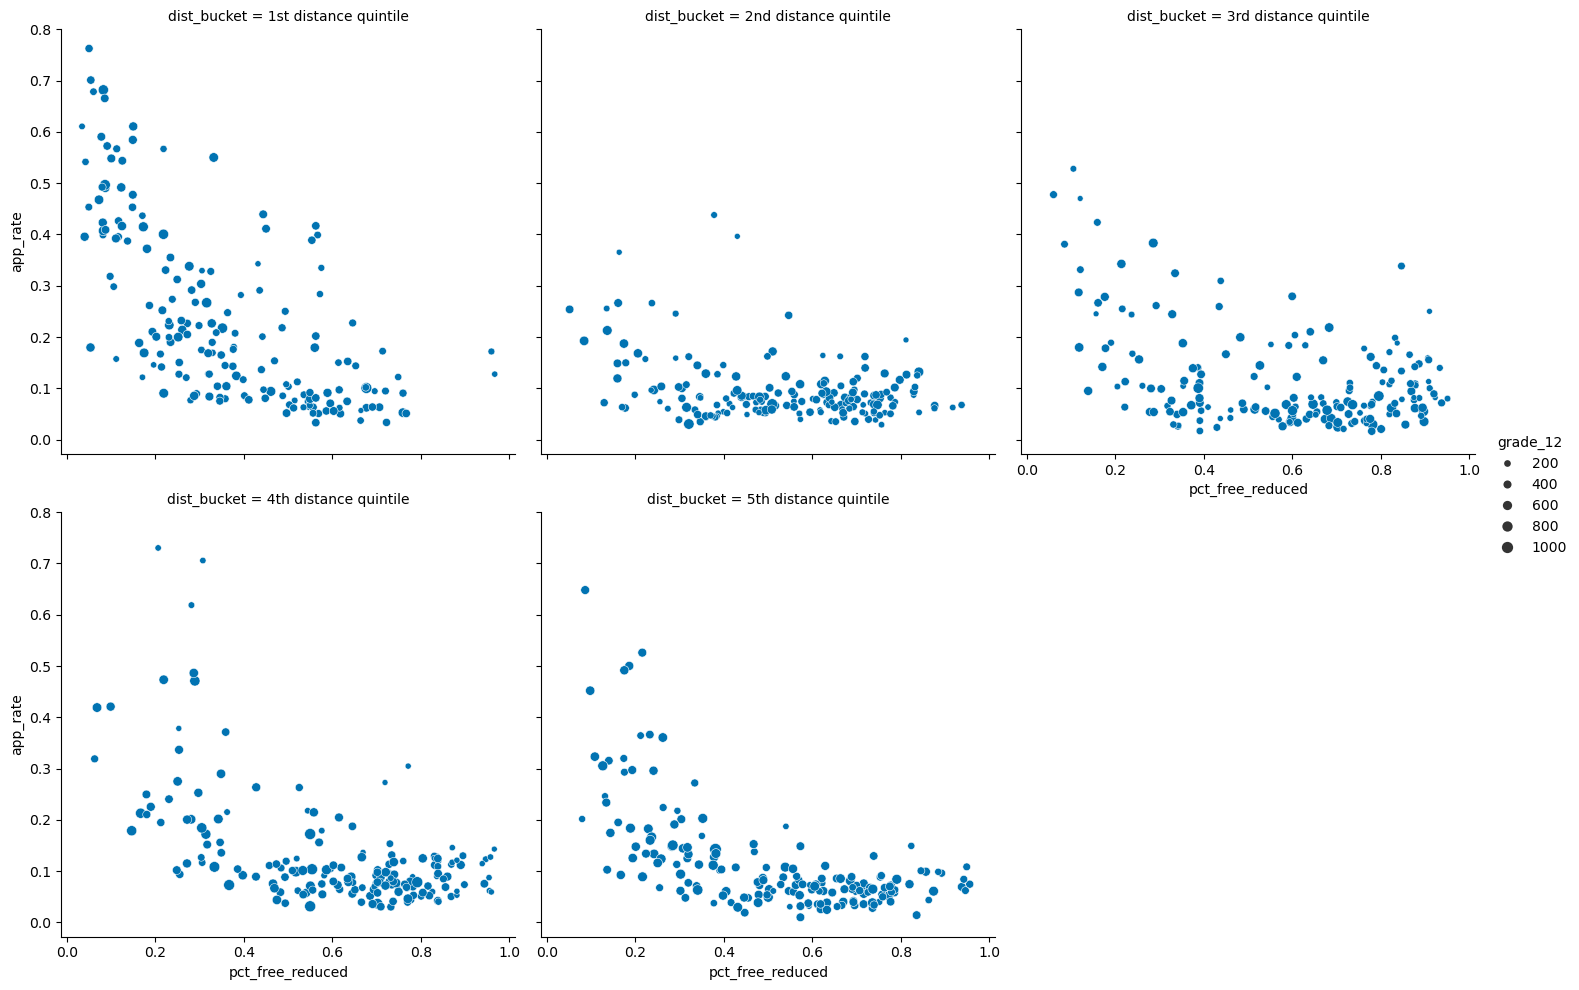

In [23]:
#| fig-alt: Five scatter plots in a grid, three on top and two below, one per distance quintile from the 1st to the 5th. Each plots app_rate from 0 to about 0.76 against pct_free_reduced from 0 to 1, on shared axes, with point size set by grade_12. In every panel, the points drift downward from left to right, with a few points sitting well above the rest of the cloud.
sns.relplot(
    pool,
    x="pct_free_reduced",
    y="app_rate",
    size="grade_12",
    col="dist_bucket",
    col_wrap=3,
    col_order=quintiles,
);

In every panel, the points drift downward from left to right: within each distance bucket, schools with more students eligible for free or reduced-price meals tend to apply at lower rates. That is the "typical pattern" our manager asked about, now drawn separately for each region of the state.

Do any schools stand out? The candidates are the points that sit far from the cloud in their own panel. A point well above the cloud on the right side of a panel is a high-FRL school whose students apply at a rate typical of much wealthier schools. A point well below the cloud on the left is a low-FRL school whose students rarely apply. Large dots matter more if we want to reach many students. Which five would you pick, and could you defend each pick to your manager?

Whatever the answer, it is a product of the choices we stated along the way. An analyst who kept charter schools, or who focused on attendance rather than applications, or who drew the distance buckets differently, could reasonably hand back a different five.

## Looking Back

Some of our choices we checked. Bounding the suppressed attendance counts with 0 and 2 showed that students admitted from low-FRL schools attend at a higher rate whatever the suppressed counts are, though the order of the other three buckets depends on them, and counting counties showed what the `25-50` distance bucket is made of. Others we checked only in part. The admission rates at the start of the chapter rest on a single random draw. EDA III's 0 and 2 fills showed that the `50-75` and `75-100` buckets admit at a higher rate than `0-25` whatever the suppressed counts are, but not by how much, and not where `25-50` falls. And the pool of 883 schools rests on decisions that a colleague could reasonably make differently.

In EDA V, we step back from this case study and look at properties worth checking in any dataset, starting with its structure and granularity.